Our recommendation is LifeSync, a personalized platform that transforms AARP from a trusted content provider into an active decision-support companion for members. Our analysis shows that Medicare users face three major challenges: too many plan choices, unclear tradeoffs between cost and quality, and ongoing enrollment changes that require timely decisions. Many members do not just need information - they need help choosing the right next step.

LifeSync addresses this by combining AARP’s trusted brand with data-driven personalization. The platform would recommend relevant content, compare healthcare and insurance options based on each user’s profile, and send timely reminders during important decision windows such as Open Enrollment. For example, a chronic-condition user may receive plans with stronger drug coverage, while a budget-conscious retiree may receive stable low-premium options.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [ ]:
file1 = "2. CY2026_Landscape_202603.csv"
file2 = "cms_achp_monthly_enrollment_performance_2026_2025_with_annual.csv"

landscape = pd.read_csv(file1, low_memory=False)
performance = pd.read_csv(file2, low_memory=False)

print("Original Landscape:", landscape.shape)
print("Original Performance:", performance.shape)

# Only remove territories
landscape = landscape[landscape["US Territory"] == "No"].copy()
performance = performance[performance["US Territory"] == "No"].copy()

print("Filtered Landscape:", landscape.shape)
print("Filtered Performance:", performance.shape)

Original Landscape: (138263, 53)
Original Performance: (138263, 221)
Filtered Landscape: (135122, 53)
Filtered Performance: (135122, 221)


In [ ]:
def clean_money_col(series):
    s = series.astype(str).str.strip()

    s = s.str.replace(r"\((.*?)\)", r"-\1", regex=True)

    s = s.str.replace("$", "", regex=False)
    s = s.str.replace(",", "", regex=False)
    s = s.str.replace("%", "", regex=False)

    s = s.replace("Not Applicable", np.nan)
    s = s.replace("Not Available", np.nan)
    s = s.replace("nan", np.nan)
    s = s.replace("", np.nan)

    return pd.to_numeric(s, errors="coerce")


def clean_numeric_col(series):
    s = series.astype(str).str.strip()

    s = s.str.replace(r"\((.*?)\)", r"-\1", regex=True)

    s = s.str.replace(",", "", regex=False)
    s = s.str.replace("%", "", regex=False)

    s = s.replace("Not Applicable", np.nan)
    s = s.replace("Not Available", np.nan)
    s = s.replace("Plan not required to report measure", np.nan)
    s = s.replace("nan", np.nan)
    s = s.replace("", np.nan)

    return pd.to_numeric(s, errors="coerce")


money_cols = [
    "Annual Part D Deductible Amount",
    "Part D Basic Premium",
    "Part D Supplemental Premium",
    "Part D Total Premium",
    "Low Income Premium Subsidy (LIPS) Amount",
    "Part D LIPS (CMS Pays)",
    "Part D Low Income Beneficiary Premium Amount",
    "Part D Out-of-Pocket (OOP) Threshold",
    "Part C Premium",
    "Monthly Consolidated Premium (Part C + D)",
    "In-Network Maximum Out-of-Pocket (MOOP) Amount"
]

rating_cols = [
    "Part C Summary Star Rating",
    "Part D Summary Star Rating",
    "Overall Star Rating",
    "SummaryRating_2026 Part C Summary",
    "SummaryRating_2026 Part D Summary",
    "SummaryRating_2026 Overall"
]

for df in [landscape, performance]:
    for col in money_cols:
        if col in df.columns:
            df[col + "_num"] = clean_money_col(df[col])

    for col in rating_cols:
        if col in df.columns:
            df[col + "_num"] = clean_numeric_col(df[col])

print("Cleaning completed.")

Cleaning completed.


In [ ]:
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 150

# Analysis 1: Medicare plan complexity by state
## Medicare is not only a content topic. It is a complex decision space that users need help navigating.

## Count number of plans by state

In [ ]:
state_plan_counts = (
    landscape
    .groupby("State Territory Name")["ContractPlanSegmentID"]
    .nunique()
    .reset_index(name="Number of Medicare Plans")
    .sort_values("Number of Medicare Plans", ascending=False)
)

display(state_plan_counts.head(15))
print(state_plan_counts["State Territory Name"].unique(), state_plan_counts["State Territory Name"].nunique())

,State Territory Name,Number of Medicare Plans
9,Florida,621
43,Texas,435
4,California,414
38,Pennsylvania,344
32,New York,228
35,Ohio,222
22,Michigan,204
33,North Carolina,187
10,Georgia,176
13,Illinois,172


['Florida' 'Texas' 'California' 'Pennsylvania' 'New York' 'Ohio'
 'Michigan' 'North Carolina' 'Georgia' 'Illinois' 'Missouri' 'Virginia'
 'Tennessee' 'Arizona' 'Indiana' 'Washington' 'Wisconsin' 'Kentucky'
 'Louisiana' 'Colorado' 'Nevada' 'Massachusetts' 'Oregon' 'Alabama'
 'South Carolina' 'Arkansas' 'Mississippi' 'Kansas' 'New Jersey'
 'Minnesota' 'Oklahoma' 'Iowa' 'New Mexico' 'West Virginia' 'Maryland'
 'Nebraska' 'Utah' 'Maine' 'Idaho' 'Connecticut' 'Hawaii' 'Delaware'
 'Montana' 'North Dakota' 'South Dakota' 'Rhode Island'
 'District of Columbia' 'New Hampshire' 'Wyoming' 'Vermont' 'Alaska'] 51


## Plot top 15 states by plan count

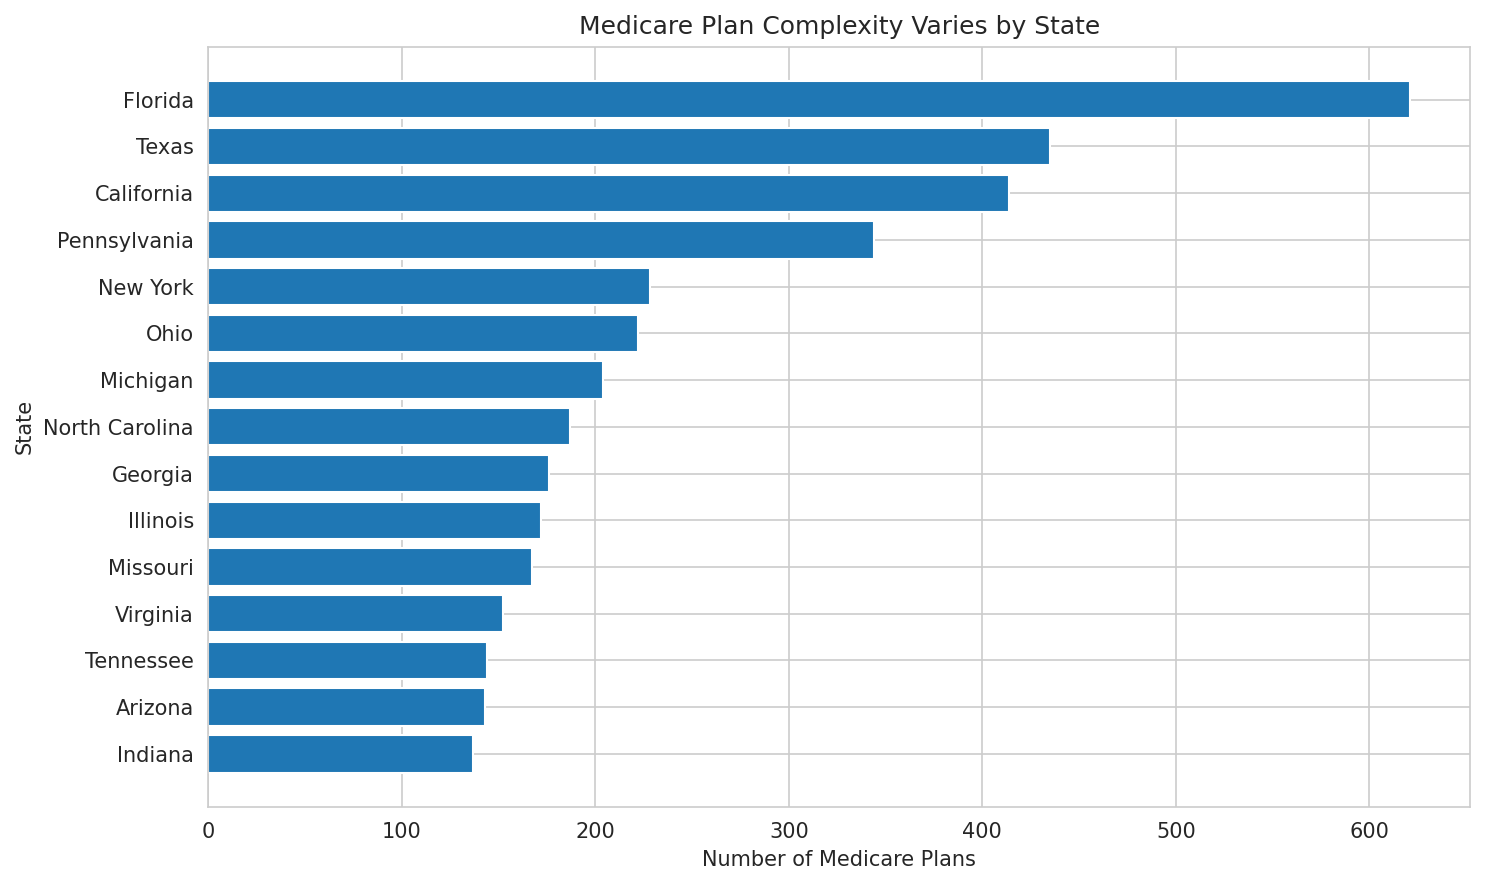

In [ ]:
top_states = state_plan_counts.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_states["State Territory Name"], top_states["Number of Medicare Plans"])
plt.gca().invert_yaxis()
plt.xlabel("Number of Medicare Plans")
plt.ylabel("State")
plt.title("Medicare Plan Complexity Varies by State")
plt.tight_layout()
plt.savefig("plan_complexity_by_state.png", dpi=300, bbox_inches="tight")
plt.show()

Medicare plan choice is highly fragmented across states, with users in major markets like Florida facing over 600 plan options. This highlights a clear need for LifeSync to simplify plan selection through personalized recommendations.

# Analysis 2: Cost vs Quality tradeoff
## LifeSync can simplify Medicare tradeoffs between cost, quality, and popularity.

In [ ]:
cost_quality = performance.copy()

cost_quality["premium"] = cost_quality["Monthly Consolidated Premium (Part C + D)_num"]
cost_quality["part_d_rating"] = cost_quality["SummaryRating_2026 Part D Summary_num"]
cost_quality["overall_rating"] = cost_quality["SummaryRating_2026 Overall_num"]

if "2025_annual_enrollment" in cost_quality.columns:
    cost_quality["annual_enrollment"] = clean_numeric_col(cost_quality["2025_annual_enrollment"])
else:
    monthly_cols = [col for col in cost_quality.columns if col.startswith("Enrollment_2025_")]
    cost_quality["annual_enrollment"] = cost_quality[monthly_cols].apply(pd.to_numeric, errors="coerce").sum(axis=1)

cost_quality_clean = cost_quality[
    cost_quality["premium"].notna() &
    cost_quality["part_d_rating"].notna() &
    cost_quality["overall_rating"].notna() &
    cost_quality["annual_enrollment"].notna()
].copy()

print(cost_quality_clean.shape)
display(cost_quality_clean[[
    "State Territory Name",
    "Parent Organization Name",
    "Plan Name",
    "premium",
    "part_d_rating",
    "overall_rating",
    "annual_enrollment"
]].head())

(82662, 242)


,State Territory Name,Parent Organization Name,Plan Name,premium,part_d_rating,overall_rating,annual_enrollment
21,Alabama,BlueCross BlueShield of Alabama,Blue Advantage Complete (PPO),35.5,3.5,3.5,9982.0
22,Alabama,BlueCross BlueShield of Alabama,Blue Advantage Premier (PPO),163.0,3.5,3.5,1045.0
23,Alabama,BlueCross BlueShield of Alabama,Blue Advantage Choice (PPO),0.0,3.5,3.5,859.0
25,Alabama,"Triton Health Systems, L.L.C.",VIVA Medicare Premier (HMO),99.0,3.0,4.0,856.0
26,Alabama,"Triton Health Systems, L.L.C.",VIVA Medicare Extra Value (HMO D-SNP),27.7,3.0,4.0,4746.0


## Scatter plot — premium vs rating

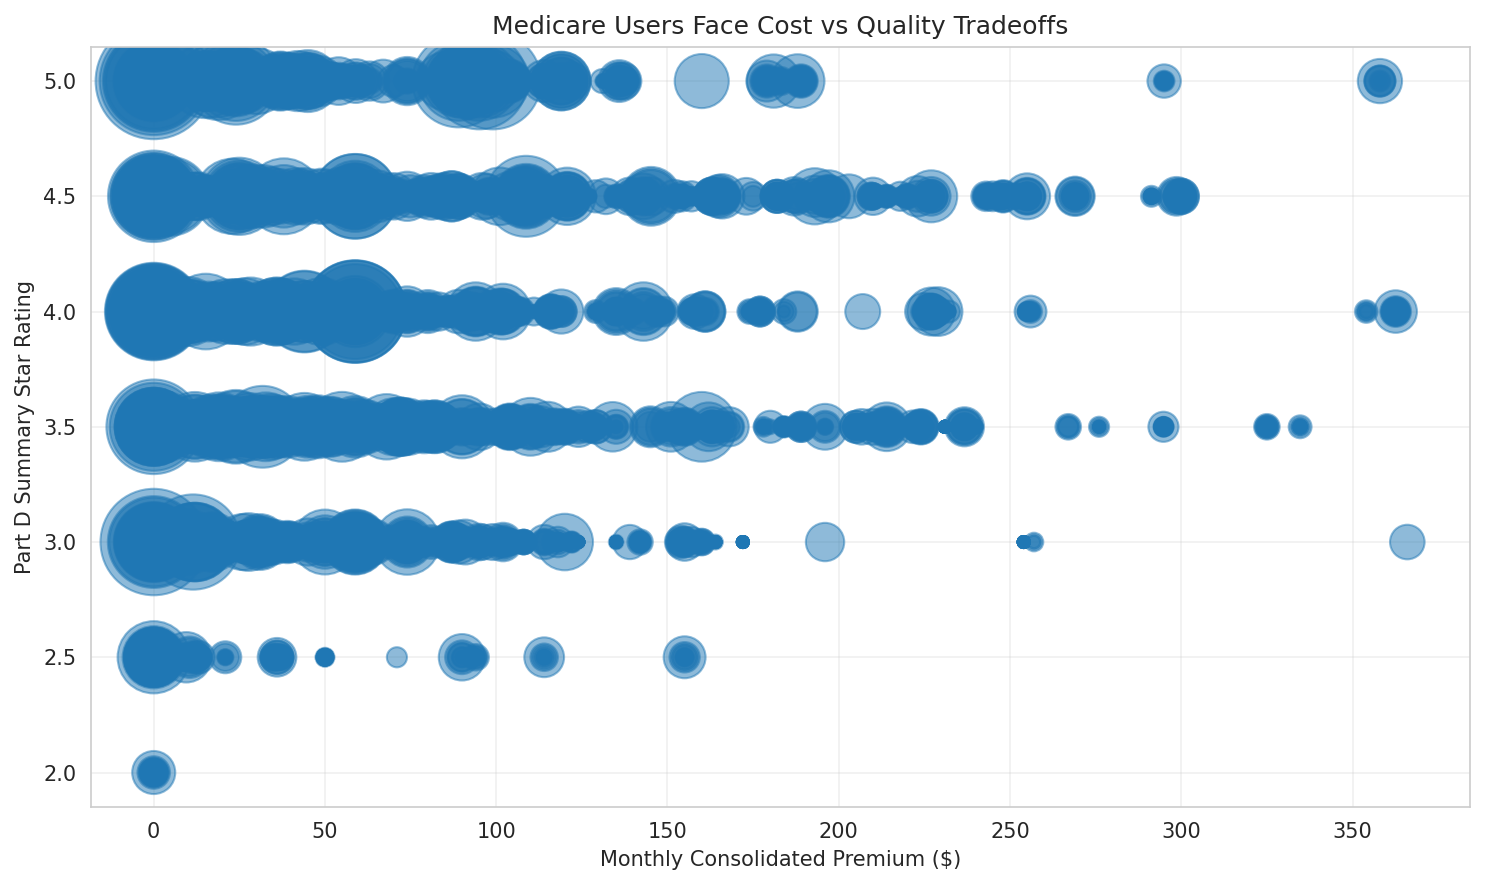

In [ ]:
plot_df = cost_quality_clean.copy()

# Avoid extremely large bubbles
plot_df["bubble_size"] = np.sqrt(plot_df["annual_enrollment"]) * 3

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_df["premium"],
    plot_df["part_d_rating"],
    s=plot_df["bubble_size"],
    alpha=0.5
)

plt.xlabel("Monthly Consolidated Premium ($)")
plt.ylabel("Part D Summary Star Rating")
plt.title("Medicare Users Face Cost vs Quality Tradeoffs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cost_quality_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

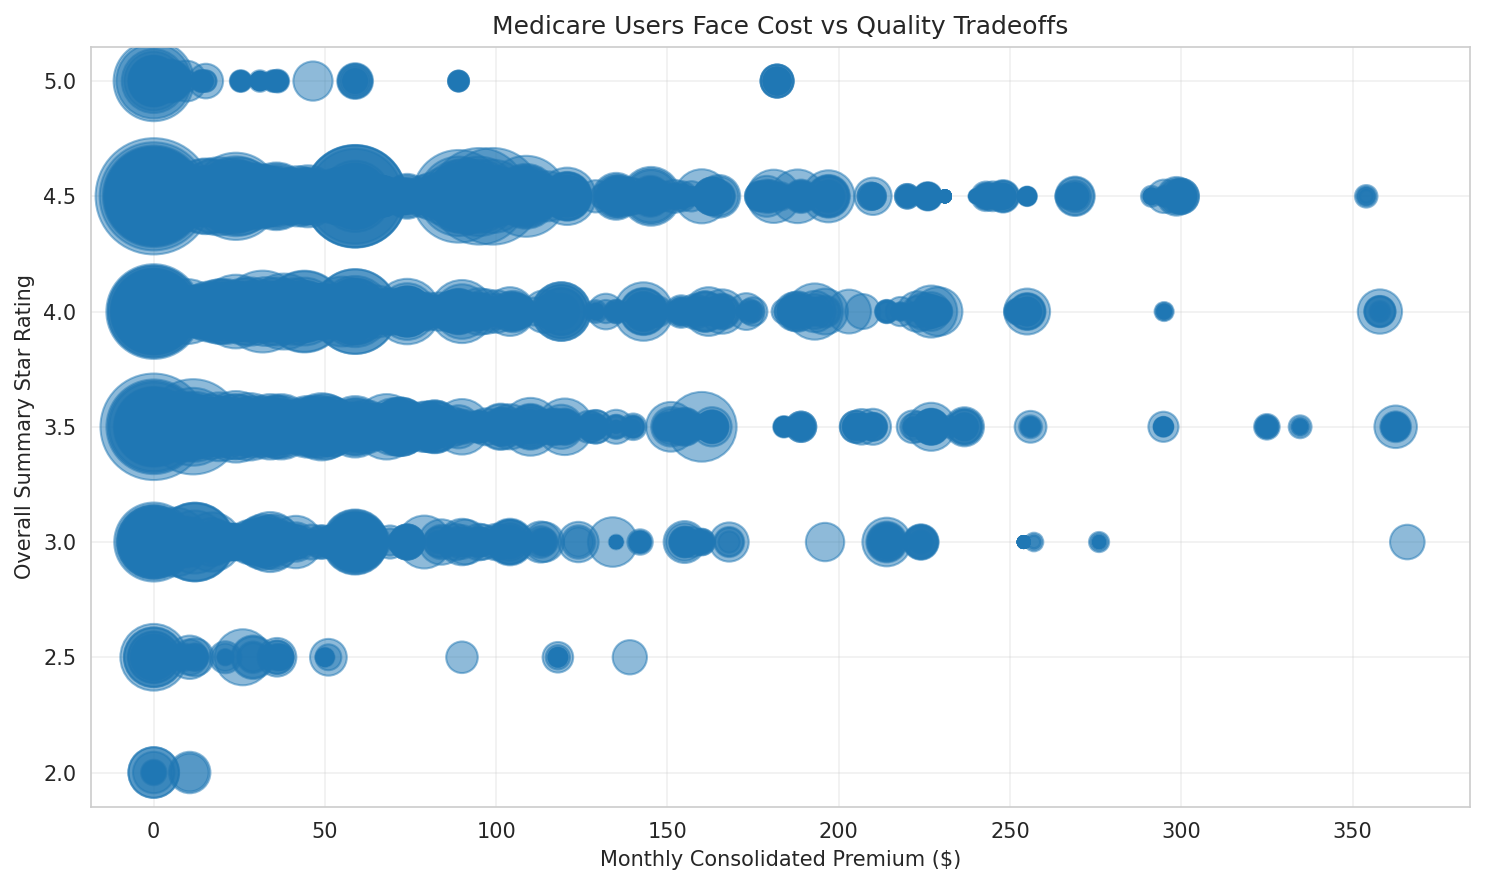

In [ ]:
plot_df = cost_quality_clean.copy()

# Avoid extremely large bubbles
plot_df["bubble_size"] = np.sqrt(plot_df["annual_enrollment"]) * 3

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_df["premium"],
    plot_df["overall_rating"],
    s=plot_df["bubble_size"],
    alpha=0.5
)

plt.xlabel("Monthly Consolidated Premium ($)")
plt.ylabel("Overall Summary Star Rating")
plt.title("Medicare Users Face Cost vs Quality Tradeoffs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cost_quality_tradeoff.png", dpi=300, bbox_inches="tight")
plt.show()

Higher premiums do not consistently translate into higher quality ratings. Since value is not obvious from price alone, LifeSync can help members compare plans based on personal needs rather than confusing raw tables.

# Analysis 3: Enrollment movement / timing opportunity
### Users do not only need Medicare information. They need timely reminders and plan review support.

## Calculate enrollment change

In [ ]:
monthly_cols = [col for col in performance.columns if col.startswith("Enrollment_2025_")]

for col in monthly_cols:
    performance[col + "_num"] = clean_numeric_col(performance[col])

performance["Enrollment_Jan"] = performance["Enrollment_2025_01_num"]
performance["Enrollment_Dec"] = performance["Enrollment_2025_12_num"]

performance["Enrollment_Change"] = performance["Enrollment_Dec"] - performance["Enrollment_Jan"]

performance["Enrollment_Change_Pct"] = np.where(
    performance["Enrollment_Jan"] > 0,
    performance["Enrollment_Change"] / performance["Enrollment_Jan"] * 100,
    np.nan
)

enrollment_change = performance[
    performance["Enrollment_Jan"].notna() &
    performance["Enrollment_Dec"].notna()
].copy()

display(enrollment_change[[
    "State Territory Name",
    "Parent Organization Name",
    "Plan Name",
    "Enrollment_Jan",
    "Enrollment_Dec",
    "Enrollment_Change",
    "Enrollment_Change_Pct"
]].head())

,State Territory Name,Parent Organization Name,Plan Name,Enrollment_Jan,Enrollment_Dec,Enrollment_Change,Enrollment_Change_Pct
0,Alaska,Centene Corporation,Wellcare Classic (PDP),2102.0,1751.0,-351.0,-16.698382
1,Alaska,Centene Corporation,Wellcare Value Script (PDP),4824.0,4664.0,-160.0,-3.316750
2,Alaska,CVS Health Corporation,SilverScript Choice (PDP),3182.0,2804.0,-378.0,-11.879321
3,Alaska,Health Care Service Corporation,HealthSpring Assurance Rx (PDP),9237.0,9963.0,726.0,7.859695
4,Alaska,Humana Inc.,Humana Basic Rx Plan (PDP),13734.0,15410.0,1676.0,12.203291


## Plot enrollment change distribution

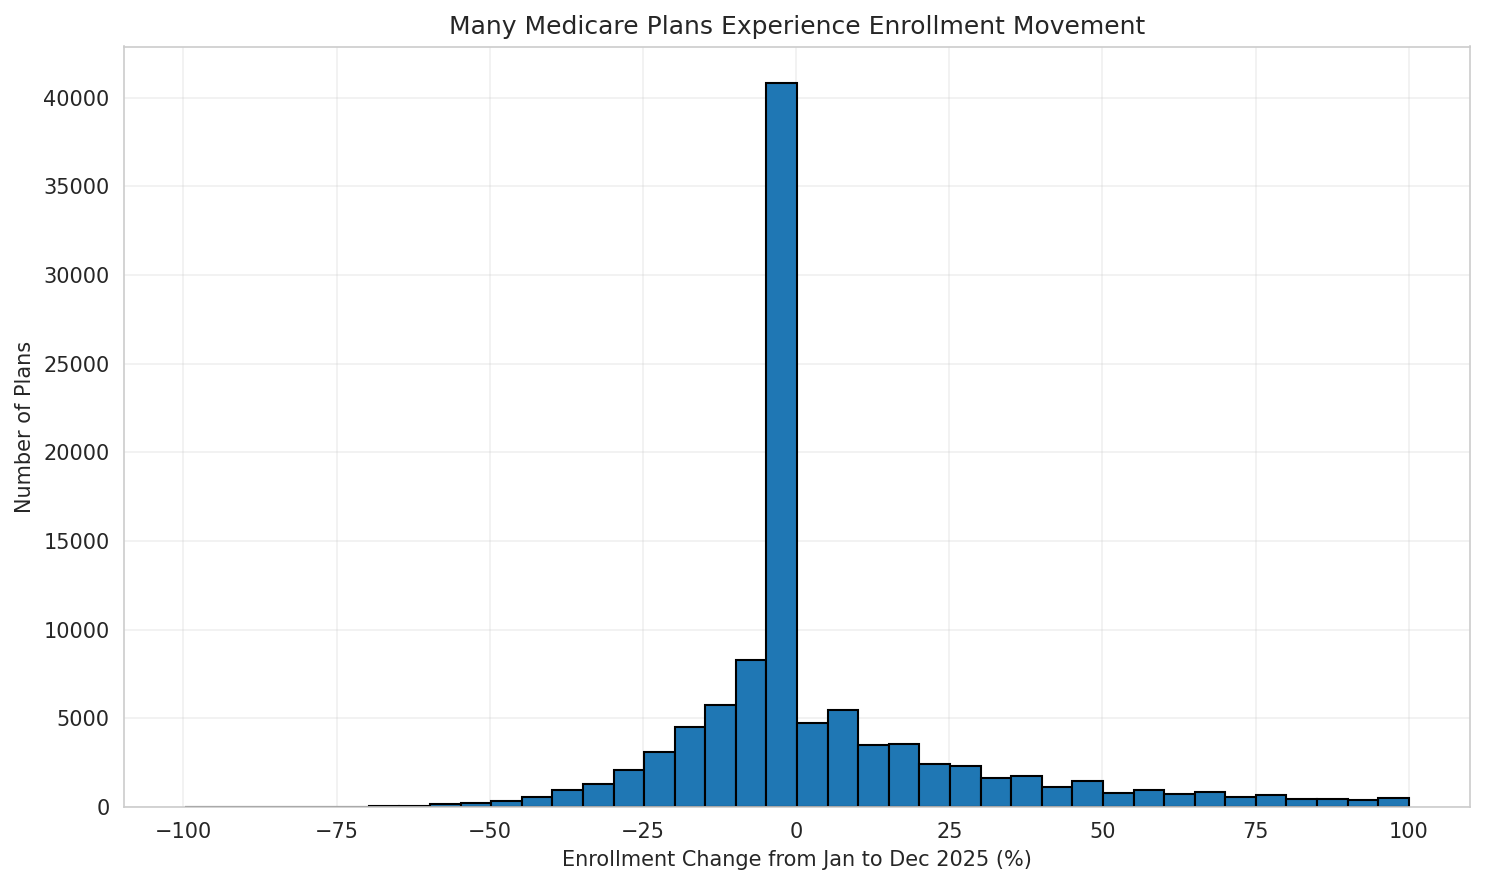

In [ ]:
plot_enroll = enrollment_change[
    enrollment_change["Enrollment_Change_Pct"].between(-100, 100)
].copy()

plt.figure(figsize=(10, 6))
plt.hist(plot_enroll["Enrollment_Change_Pct"], bins=40, edgecolor="black")
plt.xlabel("Enrollment Change from Jan to Dec 2025 (%)")
plt.ylabel("Number of Plans")
plt.title("Many Medicare Plans Experience Enrollment Movement")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("enrollment_change_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Most Medicare plans remain relatively stable, but a meaningful share show significant enrollment gains or losses over the year. This suggests members actively reassess plans over time, creating a strong opportunity for LifeSync to provide timely reminders and switching guidance during key decision windows.

# Analysis 4: Identify high- quality plans for LifeSync

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# 0. Make sure enrollment change exists
# -----------------------------

monthly_cols = [col for col in performance.columns if col.startswith("Enrollment_2025_")]

for col in monthly_cols:
    if col + "_num" not in performance.columns:
        performance[col + "_num"] = clean_numeric_col(performance[col])

if "Enrollment_Change_Pct" not in performance.columns:
    performance["Enrollment_Jan"] = performance["Enrollment_2025_01_num"]
    performance["Enrollment_Dec"] = performance["Enrollment_2025_12_num"]

    performance["Enrollment_Change"] = (
        performance["Enrollment_Dec"] - performance["Enrollment_Jan"]
    )

    performance["Enrollment_Change_Pct"] = np.where(
        performance["Enrollment_Jan"] > 0,
        performance["Enrollment_Change"] / performance["Enrollment_Jan"] * 100,
        np.nan
    )


# -----------------------------
# 1. Helper functions
# -----------------------------

def get_num_col(df, col, default=np.nan):
    if col in df.columns:
        return clean_numeric_col(df[col])
    else:
        return pd.Series(default, index=df.index)

def get_money_col(df, col, default=np.nan):
    if col in df.columns:
        return clean_money_col(df[col])
    else:
        return pd.Series(default, index=df.index)

def minmax_score(series, reverse=False):
    s = pd.to_numeric(series, errors="coerce")
    s = s.fillna(s.median())

    if s.max() == s.min():
        score = pd.Series(0.5, index=s.index)
    else:
        score = (s - s.min()) / (s.max() - s.min())

    if reverse:
        score = 1 - score

    return score

In [ ]:
# -----------------------------
# 2. Build recommendation dataset
# -----------------------------

recommend = performance.copy()

recommend["overall"] = get_num_col(recommend, "SummaryRating_2026 Overall")
recommend["partd"] = get_num_col(recommend, "SummaryRating_2026 Part D Summary")
recommend["partc"] = get_num_col(recommend, "SummaryRating_2026 Part C Summary")

recommend["premium"] = get_money_col(
    recommend, "Monthly Consolidated Premium (Part C + D)"
)

recommend["deductible"] = get_money_col(
    recommend, "Annual Part D Deductible Amount"
)

recommend["moop"] = get_money_col(
    recommend, "In-Network Maximum Out-of-Pocket (MOOP) Amount"
)

recommend["enrollment_stability"] = recommend["Enrollment_Change_Pct"].abs()


# Annual enrollment
if "2025_annual_enrollment" in recommend.columns:
    recommend["annual_enrollment"] = clean_numeric_col(
        recommend["2025_annual_enrollment"]
    )
else:
    recommend["annual_enrollment"] = recommend[
        [col + "_num" for col in monthly_cols]
    ].sum(axis=1)


# -----------------------------
# 3. Extract richer CMS indicators
# -----------------------------

# P0: convenience / flexibility / service
recommend["customer_service"] = get_num_col(
    recommend, "MeasureStars_C24: Customer Service"
)

recommend["appointments_quickly"] = get_num_col(
    recommend, "MeasureStars_C23: Getting Appointments and Care Quickly"
)

recommend["needed_care"] = get_num_col(
    recommend, "MeasureStars_C22: Getting Needed Care"
)

# P1: coordination / care continuity
recommend["care_coordination"] = get_num_col(
    recommend, "MeasureStars_C27: Care Coordination"
)

recommend["transitions_of_care"] = get_num_col(
    recommend, "MeasureStars_C20: Transitions of Care"
)

recommend["readmissions"] = get_num_col(
    recommend, "MeasureStars_C18: Plan All-Cause Readmissions"
)

# P2: drug support / chronic care
recommend["med_adherence_diabetes"] = get_num_col(
    recommend, "MeasureStars_D08: Medication Adherence for Diabetes Medications"
)

recommend["med_adherence_hypertension"] = get_num_col(
    recommend, "MeasureStars_D09: Medication Adherence for Hypertension (RAS antagonists)"
)

recommend["med_adherence_cholesterol"] = get_num_col(
    recommend, "MeasureStars_D10: Medication Adherence for Cholesterol (Statins)"
)

recommend["diabetes_eye_exam"] = get_num_col(
    recommend, "MeasureStars_C11: Diabetes Care – Eye Exam"
)

recommend["blood_sugar_control"] = get_num_col(
    recommend, "MeasureStars_C12: Diabetes Care – Blood Sugar Controlled"
)

recommend["kidney_eval"] = get_num_col(
    recommend, "MeasureStars_C13: Kidney Health Evaluation for Patients with Diabetes"
)

recommend["blood_pressure_control"] = get_num_col(
    recommend, "MeasureStars_C14: Controlling High Blood Pressure"
)


# -----------------------------
# 4. Plan type flexibility score
# -----------------------------

def plan_type_flexibility(plan_type):
    plan_type = str(plan_type).upper()

    if "PPO" in plan_type:
        return 1.0
    elif "PFFS" in plan_type:
        return 0.8
    elif "HMO" in plan_type:
        return 0.5
    elif "PDP" in plan_type:
        return 0.4
    else:
        return 0.5

recommend["plan_flexibility_score"] = recommend["Plan Type"].apply(
    plan_type_flexibility
)


# -----------------------------
# 5. Keep usable high-quality stable plans
# -----------------------------

recommend_clean = recommend[
    recommend["overall"].notna() &
    recommend["premium"].notna() &
    recommend["annual_enrollment"].notna() &
    recommend["Enrollment_Change_Pct"].notna()
].copy()

recommend_clean = recommend_clean[
    (recommend_clean["overall"] >= 3.5) &
    (recommend_clean["Enrollment_Change_Pct"].between(-10, 10)) &
    (recommend_clean["annual_enrollment"] >= 500)
].copy()

print("Usable high-quality stable plan pool:", recommend_clean.shape)


# -----------------------------
# 6. Convert indicators into scores
# -----------------------------

recommend_clean["overall_score"] = recommend_clean["overall"] / 5
recommend_clean["partd_score"] = recommend_clean["partd"].fillna(
    recommend_clean["partd"].median()
) / 5
recommend_clean["partc_score"] = recommend_clean["partc"].fillna(
    recommend_clean["partc"].median()
) / 5

recommend_clean["affordability_score"] = minmax_score(
    recommend_clean["premium"], reverse=True
)

recommend_clean["deductible_score"] = minmax_score(
    recommend_clean["deductible"], reverse=True
)

recommend_clean["moop_score"] = minmax_score(
    recommend_clean["moop"], reverse=True
)

recommend_clean["stability_score"] = minmax_score(
    recommend_clean["enrollment_stability"], reverse=True
)

recommend_clean["popularity_score"] = minmax_score(
    recommend_clean["annual_enrollment"]
)

recommend_clean["customer_service_score"] = recommend_clean["customer_service"].fillna(
    recommend_clean["customer_service"].median()
) / 5

recommend_clean["appointments_score"] = recommend_clean["appointments_quickly"].fillna(
    recommend_clean["appointments_quickly"].median()
) / 5

recommend_clean["needed_care_score"] = recommend_clean["needed_care"].fillna(
    recommend_clean["needed_care"].median()
) / 5

recommend_clean["care_coordination_score"] = recommend_clean["care_coordination"].fillna(
    recommend_clean["care_coordination"].median()
) / 5

recommend_clean["transitions_score"] = recommend_clean["transitions_of_care"].fillna(
    recommend_clean["transitions_of_care"].median()
) / 5

recommend_clean["med_adherence_score"] = (
    recommend_clean[
        [
            "med_adherence_diabetes",
            "med_adherence_hypertension",
            "med_adherence_cholesterol"
        ]
    ]
    .apply(pd.to_numeric, errors="coerce")
    .mean(axis=1)
    .fillna(recommend_clean["partd"])
    / 5
)

recommend_clean["chronic_care_score"] = (
    recommend_clean[
        [
            "diabetes_eye_exam",
            "blood_sugar_control",
            "kidney_eval",
            "blood_pressure_control"
        ]
    ]
    .apply(pd.to_numeric, errors="coerce")
    .mean(axis=1)
    .fillna(recommend_clean["overall"])
    / 5
)


# -----------------------------
# 7. Persona-specific scoring
# -----------------------------

# P0: Active Affluent Pre-Retirees
# Healthier, higher-income, still working.
# Prioritize quality, flexibility, customer service, and appointment access.
p0 = recommend_clean.copy()
p0["persona_score"] = (
    0.25 * p0["overall_score"] +
    0.20 * p0["plan_flexibility_score"] +
    0.15 * p0["customer_service_score"] +
    0.15 * p0["appointments_score"] +
    0.10 * p0["stability_score"] +
    0.10 * p0["popularity_score"] +
    0.05 * p0["partd_score"]
)

# P1: Aging Retirees
# Older, retired, moderate health decline.
# Prioritize quality, coordination, needed care, predictable risk, and stability.
p1 = recommend_clean.copy()
p1["persona_score"] = (
    0.25 * p1["overall_score"] +
    0.20 * p1["care_coordination_score"] +
    0.15 * p1["needed_care_score"] +
    0.15 * p1["moop_score"] +
    0.10 * p1["stability_score"] +
    0.10 * p1["transitions_score"] +
    0.05 * p1["affordability_score"]
)

# P2: Early Decliners
# Younger but highest chronic burden and lower income.
# Prioritize drug support, affordability, chronic care, and low deductible.
p2 = recommend_clean.copy()
p2["persona_score"] = (
    0.25 * p2["partd_score"] +
    0.20 * p2["med_adherence_score"] +
    0.20 * p2["affordability_score"] +
    0.15 * p2["chronic_care_score"] +
    0.10 * p2["deductible_score"] +
    0.10 * p2["stability_score"]
)

p0_recs = p0.sort_values("persona_score", ascending=False).head(5)
p1_recs = p1.sort_values("persona_score", ascending=False).head(5)
p2_recs = p2.sort_values("persona_score", ascending=False).head(5)

Usable high-quality stable plan pool: (14248, 288)


In [ ]:
# -----------------------------
# 8. Display recommendation dataframes
# -----------------------------

display_cols = [
    "Plan Name",
    "Parent Organization Name",
    "State Territory Name",
    "Plan Type",
    "premium",
    "deductible",
    "moop",
    "overall",
    "partd",
    "customer_service",
    "needed_care",
    "care_coordination",
    "med_adherence_score",
    "chronic_care_score",
    "annual_enrollment",
    "Enrollment_Change_Pct",
    "persona_score"
]

print("P0 Active Affluent Pre-Retirees Recommendations")
display(p0_recs[display_cols].reset_index(drop=True))

print("P1 Aging Retirees Recommendations")
display(p1_recs[display_cols].reset_index(drop=True))

print("P2 Early Decliners Recommendations")
display(p2_recs[display_cols].reset_index(drop=True))


P0 Active Affluent Pre-Retirees Recommendations


,Plan Name,Parent Organization Name,State Territory Name,Plan Type,premium,deductible,moop,overall,partd,customer_service,needed_care,care_coordination,med_adherence_score,chronic_care_score,annual_enrollment,Enrollment_Change_Pct,persona_score
0,UPMC for Life PPO High Deductible Rx (PPO),UPMC Health System,Pennsylvania,PPO,33.0,175.0,7550.0,4.5,4.5,5.0,4.0,4.0,0.866667,0.85,977.0,0.000000,0.870059
1,UPMC for Life PPO Rx Enhanced (PPO),UPMC Health System,Pennsylvania,PPO,140.0,0.0,7550.0,4.5,4.5,5.0,4.0,4.0,0.866667,0.85,706.0,0.000000,0.870026
2,MedMutual Advantage Premium (PPO),MEDICAL MUTUAL OF OHIO,Ohio,PPO,149.0,55.0,3450.0,4.5,4.0,5.0,5.0,5.0,0.733333,0.75,697.0,0.000000,0.865025
3,UPMC for Life PPO Premier Rx (PPO),UPMC Health System,Pennsylvania,PPO,0.0,500.0,6500.0,4.5,4.5,5.0,4.0,4.0,0.866667,0.85,2016.0,-0.595238,0.864236
4,Blue Medicare PPO Enhanced (PPO),CuraCor Solutions Corp.,North Carolina,PPO,53.0,100.0,6300.0,4.5,4.0,5.0,5.0,5.0,0.800000,0.75,3591.0,0.332226,0.862062


P1 Aging Retirees Recommendations


,Plan Name,Parent Organization Name,State Territory Name,Plan Type,premium,deductible,moop,overall,partd,customer_service,needed_care,care_coordination,med_adherence_score,chronic_care_score,annual_enrollment,Enrollment_Change_Pct,persona_score
0,Leon MediDual (HMO D-SNP),"LMC Family Holdings, LLC",Florida,HMO D-SNP,0.0,615.0,3450.0,5.0,5.0,5.0,5.0,5.0,1.000000,1.00,244341.0,-2.618030,0.917874
1,Leon MediExtra (HMO),"LMC Family Holdings, LLC",Florida,HMO,0.0,0.0,1000.0,5.0,5.0,5.0,5.0,5.0,1.000000,1.00,184050.0,-7.822855,0.905555
2,DEVOTED CORE 001 NC (HMO),"Devoted Health, Inc.",North Carolina,HMO,0.0,395.0,3600.0,5.0,4.5,5.0,4.0,5.0,0.933333,0.95,5835.0,0.000000,0.891622
3,PriorityMedicare Value (HMO-POS),Corewell Health,Michigan,HMO-POS,32.0,100.0,5100.0,4.5,4.5,4.0,5.0,5.0,0.733333,0.90,43323.0,0.111328,0.886771
4,Generations Classic Rewards (HMO),"MHH Healthcare, L.P.",Oklahoma,HMO,0.0,0.0,3900.0,4.0,3.5,4.0,5.0,5.0,0.600000,0.95,746.0,0.000000,0.886757


P2 Early Decliners Recommendations


,Plan Name,Parent Organization Name,State Territory Name,Plan Type,premium,deductible,moop,overall,partd,customer_service,needed_care,care_coordination,med_adherence_score,chronic_care_score,annual_enrollment,Enrollment_Change_Pct,persona_score
0,Kaiser Permanente Medicare Advantage Centennia...,"Kaiser Foundation Health Plan, Inc.",Washington,HMO,0.0,0.0,4950.0,4.0,5.0,4.0,1.0,3.0,1.000000,0.85,66049.0,0.602410,0.971476
1,Kaiser Permanente Medicare Advantage Standard ...,"Kaiser Foundation Health Plan, Inc.",Virginia,HMO-POS,15.0,0.0,5900.0,4.5,5.0,3.0,1.0,3.0,0.933333,0.95,68586.0,-0.297411,0.967919
2,Kaiser Permanente Senior Advantage Standard (H...,"Kaiser Foundation Health Plan, Inc.",Washington,HMO-POS,37.0,0.0,4500.0,4.0,5.0,3.0,1.0,1.0,0.933333,1.00,65102.0,-0.147221,0.964786
3,Kaiser Permanente Senior Advantage Standard (H...,"Kaiser Foundation Health Plan, Inc.",Oregon,HMO-POS,37.0,0.0,4500.0,4.0,5.0,3.0,1.0,1.0,0.933333,1.00,49475.0,0.194505,0.964313
4,Kaiser Permanente Medicare Advantage Value 1 V...,"Kaiser Foundation Health Plan, Inc.",Virginia,HMO-POS,0.0,0.0,6500.0,4.5,5.0,3.0,1.0,3.0,0.933333,0.95,4885.0,1.496259,0.964204


P0

These recommendations were generated by assigning higher weights to factors that matter most to the P0 persona: **overall plan quality, provider flexibility, customer service, quick appointment access, and enrollment stability**. P0 members are generally healthier, higher-income, and often still working, so they are less focused on the absolute lowest premium and more focused on convenience, reliable service, and broad network choice. Therefore, plans with strong ratings, PPO-style flexibility, and stable member satisfaction naturally rank highest. This is reasonable because this group values efficiency, choice, and long-term quality over purely minimizing monthly cost.

P1

These recommendations were generated by emphasizing the needs of ***older retired members***: strong overall quality, care coordination, access to needed care, lower out-of-pocket risk, and plan stability. P1 members are older and more likely to need frequent healthcare interactions, so seamless coordination between providers and predictable financial exposure become more important than network flexibility. As a result, plans with lower MOOP, stronger coordination scores, and stable enrollment rank highest. This is reasonable because older retirees often prioritize security, continuity of care, and manageable medical costs.

P2

These recommendations were generated by prioritizing factors most relevant to members with **higher chronic-condition burden and lower income**: Part D quality, medication adherence performance, affordability, chronic-care quality, low deductibles, and stability. P2 members are more likely to rely on prescriptions and ongoing treatment, so drug coverage and affordable costs have a much greater impact on their daily well-being. Therefore, plans with strong Part D ratings, lower premiums, lower deductibles, and better chronic-care measures rank highest. This is reasonable because this group benefits most from plans that reduce financial strain while supporting continuous treatment.

In [ ]:
# -----------------------------
# 9. Print explanation
# -----------------------------

def explain_plan_recommendations(persona_name, recs, persona_logic):
    print("=" * 100)
    print(persona_name)
    print("=" * 100)
    print("Persona recommendation logic:")
    print(persona_logic)
    print("\nTop recommended plans:")

    for i, row in recs.reset_index(drop=True).iterrows():
        print(f"\n#{i+1}: {row['Plan Name']} | {row['Parent Organization Name']}")
        print(f"State: {row['State Territory Name']} | Plan Type: {row['Plan Type']}")
        print(
            f"Premium: ${row['premium']:.2f} | "
            f"Overall: {row['overall']} | "
            f"Part D: {row['partd']} | "
            f"Enrollment change: {row['Enrollment_Change_Pct']:.1f}%"
        )

        strengths = []

        if row["overall"] >= 4.5:
            strengths.append("high overall quality")
        if pd.notna(row["partd"]) and row["partd"] >= 4.5:
            strengths.append("strong drug plan performance")
        if row["premium"] <= 20:
            strengths.append("low monthly premium")
        if pd.notna(row["moop"]) and row["moop"] <= recommend_clean["moop"].median():
            strengths.append("lower out-of-pocket risk")
        if abs(row["Enrollment_Change_Pct"]) <= 5:
            strengths.append("stable enrollment")
        if pd.notna(row["customer_service"]) and row["customer_service"] >= 4:
            strengths.append("strong customer service")
        if pd.notna(row["care_coordination"]) and row["care_coordination"] >= 4:
            strengths.append("strong care coordination")
        if row["med_adherence_score"] >= 0.8:
            strengths.append("strong medication adherence performance")
        if row["chronic_care_score"] >= 0.8:
            strengths.append("strong chronic-care performance")
        if "PPO" in str(row["Plan Type"]).upper():
            strengths.append("more provider flexibility")

        if strengths:
            print("Why this plan fits: " + ", ".join(strengths) + ".")
        else:
            print("Why this plan fits: balanced quality, cost, and stability.")

    print("\n")


explain_plan_recommendations(
    "P0 Active Affluent Pre-Retirees",
    p0_recs,
    "P0 is healthier, higher-income, and often still working. LifeSync prioritizes plan quality, provider flexibility, customer service, appointment access, and stable enrollment."
)

explain_plan_recommendations(
    "P1 Aging Retirees",
    p1_recs,
    "P1 is older and retired with moderate health decline. LifeSync prioritizes overall quality, care coordination, needed care access, lower out-of-pocket risk, and stability."
)

explain_plan_recommendations(
    "P2 Early Decliners",
    p2_recs,
    "P2 has the highest chronic burden and lower income. LifeSync prioritizes Part D quality, medication adherence, affordability, chronic-care performance, low deductible, and stability."
)




P0 Active Affluent Pre-Retirees
Persona recommendation logic:
P0 is healthier, higher-income, and often still working. LifeSync prioritizes plan quality, provider flexibility, customer service, appointment access, and stable enrollment.

Top recommended plans:

#1: UPMC for Life PPO High Deductible Rx (PPO) | UPMC Health System
State: Pennsylvania | Plan Type: PPO
Premium: $33.00 | Overall: 4.5 | Part D: 4.5 | Enrollment change: 0.0%
Why this plan fits: high overall quality, strong drug plan performance, stable enrollment, strong customer service, strong care coordination, strong medication adherence performance, strong chronic-care performance, more provider flexibility.

#2: UPMC for Life PPO Rx Enhanced (PPO) | UPMC Health System
State: Pennsylvania | Plan Type: PPO
Premium: $140.00 | Overall: 4.5 | Part D: 4.5 | Enrollment change: 0.0%
Why this plan fits: high overall quality, strong drug plan performance, stable enrollment, strong customer service, strong care coordination, strong